Student Name: Vaishnavi Raut

Student ID: 202301100003

Date: 09-04-2026

Assignment Title: NLP Preprocessing and Text Classification





In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
import string

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [8]:
from google.colab import files
uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset.csv


In [9]:
df = pd.read_csv("IMDB Dataset.csv")

print(df.columns)
df.head()

Index(['review', 'sentiment'], dtype='object')


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [10]:
df = df[['review', 'sentiment']]
df.columns = ['text', 'target']

# Convert labels to numeric
df['target'] = df['target'].map({'positive': 1, 'negative': 0})

print("Dataset shape:", df.shape)

Dataset shape: (50000, 2)


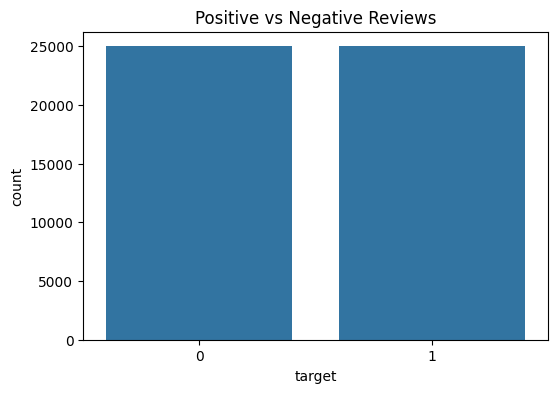

target
1    25000
0    25000
Name: count, dtype: int64


In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df)
plt.title('Positive vs Negative Reviews')
plt.show()

print(df['target'].value_counts())

In [12]:
print(df['text'].iloc[0][:500])

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ


In [13]:
df['text_length'] = df['text'].apply(len)

print("Average:", df['text_length'].mean())
print("Min:", df['text_length'].min())
print("Max:", df['text_length'].max())

Average: 1309.43102
Min: 32
Max: 13704


In [14]:
sample = df['text'].iloc[0]

tokens = word_tokenize(sample.lower())
tokens = [w for w in tokens if w not in string.punctuation]

stop_words = set(stopwords.words('english'))
tokens = [w for w in tokens if w not in stop_words]

stemmer = PorterStemmer()
tokens = [stemmer.stem(w) for w in tokens]

lemmatizer = WordNetLemmatizer()
tokens = [lemmatizer.lemmatize(w) for w in tokens]

print(tokens[:50])

['one', 'review', 'mention', 'watch', '1', 'oz', 'episod', "'ll", 'hook', 'right', 'exactli', 'happen', 'me.', 'br', 'br', 'first', 'thing', 'struck', 'oz', 'brutal', 'unflinch', 'scene', 'violenc', 'set', 'right', 'word', 'go', 'trust', 'show', 'faint', 'heart', 'timid', 'show', 'pull', 'punch', 'regard', 'drug', 'sex', 'violenc', 'hardcor', 'classic', 'use', 'word.', 'br', 'br', 'call', 'oz', 'nicknam', 'given', 'oswald']


In [ ]:
def preprocess_text(text):
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in string.punctuation]

    stop_words = set(stopwords.words('english'))
    tokens = [w for w in tokens if w not in stop_words]

    stemmer = PorterStemmer()
    tokens = [stemmer.stem(w) for w in tokens]

    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(w) for w in tokens]

    return ' '.join(tokens)

df['processed_text'] = df['text'].apply(preprocess_text)

In [ ]:
X = df['processed_text']
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
cv = CountVectorizer(max_features=5000)

X_train_cv = cv.fit_transform(X_train)
X_test_cv = cv.transform(X_test)

In [ ]:
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))

In [ ]:
print(classification_report(y_test, y_pred))

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()

=== CONCLUSION ===

- NLP preprocessing improves model performance
- TF-IDF works better than CountVectorizer
- Naive Bayes is effective for text classification
- The model successfully classifies sentiment